In [1]:
import pandas as pd
df = pd.read_spss(r"C:\Users\Surface\Downloads\HA filler (1).sav")

## 0. Setup

In [2]:
# Install dependencies. Set to False once they are installed.
INSTALL = True

if INSTALL:
    import sys, subprocess
    pkgs = ["pandas", "numpy", "scipy", "scikit-learn>=1.4", "matplotlib",
            "pyreadstat", "tableone", "statsmodels", "xgboost", "shap", "openpyxl"]
    subprocess.run([sys.executable, "-m", "pip", "install", "-q", *pkgs], check=False)
    print("dependency install attempted — restart the kernel if anything was upgraded")

dependency install attempted — restart the kernel if anything was upgraded


In [3]:
# ============================== CONFIGURATION ==============================
from pathlib import Path

# --- 1. Path to your SPSS file -------------------------------------------------
DATA_PATH = Path("HA filler (1).sav")     # <-- EDIT THIS

# --- 2. Run size ---------------------------------------------------------------
FAST_MODE = False     # True = quick check (minutes). False = full analysis (hours).

# --- 3. Everything else --------------------------------------------------------
OUTDIR    = Path("results")
SEED      = 42
N_JOBS    = -1        # set to 1 if you hit pickling errors on Windows

if FAST_MODE:
    N_IMPUTATIONS, N_ITER_SEARCH, N_BOOTSTRAP, MICE_ITER = 2, 4, 300, 5
else:
    N_IMPUTATIONS, N_ITER_SEARCH, N_BOOTSTRAP, MICE_ITER = 5, 12, 2000, 10

OUTER_SPLITS, INNER_SPLITS = 5, 3

(OUTDIR / "tables").mkdir(parents=True, exist_ok=True)
(OUTDIR / "figures").mkdir(parents=True, exist_ok=True)

print(f"mode          : {'FAST (smoke test)' if FAST_MODE else 'FULL'}")
print(f"imputations   : {N_IMPUTATIONS}")
print(f"search budget : {N_ITER_SEARCH}")
print(f"data file     : {DATA_PATH}   (exists: {DATA_PATH.exists()})")
if not DATA_PATH.exists():
    print("\\n>>> Edit DATA_PATH above before continuing.")

mode          : FULL
imputations   : 5
search budget : 12
data file     : HA filler (1).sav   (exists: False)
\n>>> Edit DATA_PATH above before continuing.


In [4]:
# ================================= IMPORTS =================================
import json, re, time, warnings
from dataclasses import dataclass
from typing import Any, Dict, List, Optional, Sequence, Tuple

import numpy as np
import pandas as pd
import matplotlib
import matplotlib.pyplot as plt

from sklearn.base import BaseEstimator, TransformerMixin, clone
from sklearn.compose import ColumnTransformer
from sklearn.ensemble import AdaBoostClassifier, RandomForestClassifier
from sklearn.experimental import enable_iterative_imputer   # noqa: F401
from sklearn.impute import IterativeImputer, SimpleImputer
from sklearn.inspection import permutation_importance
from sklearn.linear_model import BayesianRidge, LogisticRegression
from sklearn.metrics import (accuracy_score, auc, average_precision_score,
                             balanced_accuracy_score, brier_score_loss,
                             confusion_matrix, f1_score, matthews_corrcoef,
                             precision_recall_curve, roc_auc_score, roc_curve)
from sklearn.model_selection import (GridSearchCV, RandomizedSearchCV,
                                     StratifiedKFold, cross_val_predict)
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier

warnings.filterwarnings("ignore", category=FutureWarning)
warnings.filterwarnings("ignore", category=UserWarning)
np.random.seed(SEED)

# ---- study constants ----------------------------------------------------------
VISIT_MONTH = {"V0": 0.0, "V2": 0.5, "V3": 3.0, "V4": 6.0}   # V2 = week 2, V3 = month 3
VISITS      = ("V0", "V2", "V3")
TARGET_CONT = "satisfactionV4"
OUTCOME_BIN = "failure"
FAILURE_THRESHOLD = 7.0
SENSITIVITY_THRESHOLDS = (6.0, 7.0, 8.0)
ORDINAL_SEVERITY_MAP = {"none":0,"None":0,"mild":1,"Mild":1,"moderate":2,"Moderate":2,
                        "severe":3,"Severe":3,"extreme":4,"Extreme":4}
BASELINE_EXACT = ["group","sex","age","pain","injectionR","injectionL","totalinjectionV1"]

def savefig(fig, name):
    fig.savefig(OUTDIR/"figures"/f"{name}.png", dpi=300, bbox_inches="tight")
    fig.savefig(OUTDIR/"figures"/f"{name}.pdf", bbox_inches="tight")
    print(f"  saved -> figures/{name}.png | .pdf")

def save_table(df, name, index=False):
    df.to_csv(OUTDIR/"tables"/f"{name}.csv", index=index, encoding="utf-8-sig")
    print(f"  saved -> tables/{name}.csv  {df.shape}")

import sklearn
print("pandas", pd.__version__, "| numpy", np.__version__, "| scikit-learn", sklearn.__version__)

pandas 2.2.2 | numpy 1.26.4 | scikit-learn 1.5.1


## 1. Load the data and build the outcome

The outcome rule is a single criterion: **satisfaction at month 6 below 7 = treatment
failure**. Every patient with a month-6 assessment is classified; there is no gap.

In [5]:
df_raw = pd.read_spss(r"C:\Users\Surface\Downloads\HA filler (1).sav")
df_raw = df_raw.reset_index(drop=True)
df_raw.insert(0, "patient_id", np.arange(1, len(df_raw) + 1))

print(f"raw shape        : {df_raw.shape[0]} patients x {df_raw.shape[1]-1} variables")
print(f"duplicate rows   : {df_raw.duplicated().sum()}")

miss = (pd.DataFrame({"variable": df_raw.columns,
                      "missing_n": df_raw.isna().sum().values,
                      "missing_pct": (df_raw.isna().mean()*100).round(2).values})
        .query("missing_n > 0").sort_values("missing_n", ascending=False)
        .reset_index(drop=True))
save_table(miss, "T00_missingness")
display(miss.head(20))

raw shape        : 210 patients x 48 variables
duplicate rows   : 0
  saved -> tables/T00_missingness.csv  (37, 3)


,variable,missing_n,missing_pct
0,densityV4,40,19.05
1,thicknessV4,40,19.05
2,satisfactionV4,39,18.57
3,volumeRV4,39,18.57
4,allerganV4,39,18.57
5,allergan2V4,39,18.57
6,areaRV4,39,18.57
7,depthRV4,39,18.57
8,depthLV4,39,18.57
9,areaLV4,39,18.57


In [6]:
# ---- attrition: are the excluded patients different? --------------------------
from scipy import stats

d = df_raw.copy()
d["_dropped"] = d[TARGET_CONT].isna().astype(int)
rows = []
for col in [c for c in d.columns if c not in ("patient_id","_dropped") and not re.search(r"V4$", c)]:
    keep, drop = d.loc[d._dropped==0, col], d.loc[d._dropped==1, col]
    if pd.api.types.is_numeric_dtype(d[col]):
        k, dr = keep.dropna(), drop.dropna()
        if len(k) < 3 or len(dr) < 3: continue
        p = stats.mannwhitneyu(k, dr, alternative="two-sided").pvalue
        rows.append({"variable":col,"analysed":f"{k.median():.2f}","excluded":f"{dr.median():.2f}",
                     "test":"Mann-Whitney U","p_value":round(p,4)})
    else:
        ct = pd.crosstab(d[col], d._dropped)
        if ct.shape[0] < 2 or ct.shape[1] < 2: continue
        p = stats.chi2_contingency(ct.values)[1]
        rows.append({"variable":col,"analysed":"-","excluded":"-",
                     "test":"Chi-square","p_value":round(p,4)})

dropout = pd.DataFrame(rows).sort_values("p_value").reset_index(drop=True)
try:
    from statsmodels.stats.multitest import multipletests
    dropout["q_BH"] = multipletests(dropout.p_value, method="fdr_bh")[1].round(4)
except Exception:
    pass
save_table(dropout, "T00_dropout_analysis")
print(f"excluded (no month-6 outcome): {int(d._dropped.sum())} of {len(d)} "
      f"({d._dropped.mean()*100:.1f}%)")
display(dropout.head(10))

  saved -> tables/T00_dropout_analysis.csv  (37, 6)
excluded (no month-6 outcome): 39 of 210 (18.6%)


,variable,analysed,excluded,test,p_value,q_BH
0,allergan2V2,-,-,Chi-square,0.0036,0.0796
1,allerganV2,-,-,Chi-square,0.0043,0.0796
2,volumeRV0,39.00,63.52,Mann-Whitney U,0.0113,0.1073
3,densityV0,32.13,26.55,Mann-Whitney U,0.0123,0.1073
4,pain,4.00,5.00,Mann-Whitney U,0.0145,0.1073
5,volumeRV3,29.03,41.21,Mann-Whitney U,0.0239,0.1406
6,areaRV0,3.83,5.22,Mann-Whitney U,0.0266,0.1406
7,areaRV3,2.77,3.81,Mann-Whitney U,0.0332,0.1536
8,satisfactionV2,8.50,8.00,Mann-Whitney U,0.0434,0.1784
9,areaLV0,3.92,5.04,Mann-Whitney U,0.0563,0.1847


In [7]:
df = df_raw.dropna(subset=[TARGET_CONT]).copy()
df[OUTCOME_BIN] = (df[TARGET_CONT].astype(float) < FAILURE_THRESHOLD).astype(int)
y = df[OUTCOME_BIN].values.astype(int)

n_fail = int(y.sum())
NO_INFO_RATE = float((y == 0).mean())
print(f"analysis cohort  : n = {len(df)}")
print(f"treatment failure: {n_fail} ({y.mean()*100:.1f}%)   rule: {TARGET_CONT} < {FAILURE_THRESHOLD:g}")
print(f"responders       : {len(y)-n_fail} ({(1-y.mean())*100:.1f}%)")
print(f"no-information rate (majority-class accuracy) = {NO_INFO_RATE:.4f}")
print(f"events per candidate variable, 37 variables   = {n_fail/37:.2f}   (conventional minimum 10)")

print("\ndistribution of the outcome score:")
display(df[TARGET_CONT].value_counts().sort_index().to_frame("n patients").T)

analysis cohort  : n = 171
treatment failure: 50 (29.2%)   rule: satisfactionV4 < 7
responders       : 121 (70.8%)
no-information rate (majority-class accuracy) = 0.7076
events per candidate variable, 37 variables   = 1.35   (conventional minimum 10)

distribution of the outcome score:


satisfactionV4,0.0,1.0,2.0,3.0,4.0,5.0,6.0,7.0,8.0,9.0,10.0
n patients,4,6,3,5,5,18,9,18,31,17,55


## 2. Descriptive tables

Table 1 (baseline) and Table 2 (follow-up), stratified by outcome. The p-values are
unadjusted; the cell after them applies a false-discovery-rate correction across all
comparisons, which matters because 37 tests are reported.

In [8]:
from tableone import TableOne

baseline_cols = [c for c in ["group","age","sex","allerganV0","allergan2V0",
    "depthRV0","areaRV0","volumeRV0","depthLV0","areaLV0","volumeLV0",
    "thicknessV0","densityV0","injectionR","injectionL","totalinjectionV1","pain"]
    if c in df.columns]
cat1 = [c for c in ["group","sex","allerganV0","allergan2V0"] if c in df.columns]
nn1  = [c for c in baseline_cols if c.startswith(("pain","volume","area","depth","thickness","density"))]

t1 = TableOne(df, columns=baseline_cols, categorical=cat1, groupby=OUTCOME_BIN,
              nonnormal=nn1, pval=True, missing=True)
t1.to_csv(OUTDIR/"tables"/"T01_baseline_by_outcome.csv")
print("TABLE 1 — baseline characteristics by outcome  (0 = responder, 1 = failure)\n")
print(t1.tabulate(tablefmt="simple"))

TABLE 1 — baseline characteristics by outcome  (0 = responder, 1 = failure)

                                       Missing    Overall                 0                       1                       P-Value
---------------------------  --------  ---------  ----------------------  ----------------------  ----------------------  ---------
n                                                 171                     121                     50
group, n (%)                 lonagel              25 (14.6)               19 (15.7)               6 (12.0)                0.032
                             mizan                25 (14.6)               22 (18.2)               3 (6.0)
                             nuxiwell             27 (15.8)               19 (15.7)               8 (16.0)
                             perjuns              24 (14.0)               13 (10.7)               11 (22.0)
                             pouya                26 (15.2)               14 (11.6)               12 (24.0)
   

In [9]:
v23 = [c for c in ["satisfactionV2","satisfactionV3","allerganV2","allergan2V2",
    "allerganV3","allergan2V3","depthRV2","areaRV2","volumeRV2","depthLV2","areaLV2",
    "volumeLV2","thicknessV2","densityV2","depthRV3","areaRV3","volumeRV3",
    "depthLV3","areaLV3","volumeLV3"] if c in df.columns]
cat2 = [c for c in ["allerganV2","allergan2V2","allerganV3","allergan2V3"] if c in df.columns]

t2 = TableOne(df, columns=v23, categorical=cat2, groupby=OUTCOME_BIN,
              nonnormal=[c for c in v23 if c not in cat2], pval=True, missing=True)
t2.to_csv(OUTDIR/"tables"/"T02_followup_by_outcome.csv")
print("TABLE 2 — follow-up characteristics by outcome\n")
print(t2.tabulate(tablefmt="simple"))

TABLE 2 — follow-up characteristics by outcome

                                          Missing    Overall                 0                       1                       P-Value
------------------------------  --------  ---------  ----------------------  ----------------------  ----------------------  ---------
n                                                    171                     121                     50
satisfactionV2, median [Q1,Q3]            9          8.5 [7.0,10.0]          9.0 [8.0,10.0]          8.0 [6.0,9.0]           <0.001
satisfactionV3, median [Q1,Q3]            6          8.0 [6.0,10.0]          8.0 [7.0,10.0]          5.0 [4.0,7.0]           <0.001
allerganV2, n (%)               Mild                 92 (53.8)               71 (58.7)               21 (42.0)               0.013
                                Moderate             56 (32.7)               32 (26.4)               24 (48.0)
                                None                 20 (11.7)            

In [10]:
# ---- multiple-comparison correction across Tables 1 and 2 ---------------------
def _pvals(t):
    out = {}
    for k, v in t.tableone.iterrows():
        name = k[0] if isinstance(k, tuple) else k
        for col in t.tableone.columns:
            if "P-Value" in str(col):
                val = str(v[col]).strip()
                if val and val not in ("", "nan"):
                    try:
                        out[name.split(",")[0]] = 0.0005 if val.startswith("<") else float(val)
                    except ValueError:
                        pass
    return out

allp = {**{f"T1:{k}": v for k, v in _pvals(t1).items()},
        **{f"T2:{k}": v for k, v in _pvals(t2).items()}}
names, ps = list(allp), np.array(list(allp.values()))
from statsmodels.stats.multitest import multipletests
rej, q, _, _ = multipletests(ps, alpha=0.05, method="fdr_bh")
mc = (pd.DataFrame({"variable":names, "raw_p":ps, "q_BH":q.round(4), "survives_FDR":rej})
      .sort_values("raw_p").reset_index(drop=True))
save_table(mc, "T03_multiple_comparisons")
print(f"{len(ps)} comparisons reported; {int(rej.sum())} survive FDR correction:")
display(mc.head(10))

  saved -> tables/T03_multiple_comparisons.csv  (37, 4)
37 comparisons reported; 2 survive FDR correction:


,variable,raw_p,q_BH,survives_FDR
0,T2:satisfactionV3,0.0005,0.0092,True
1,T2:satisfactionV2,0.0005,0.0092,True
2,T2:allerganV2,0.0130,0.1603,False
3,T1:group,0.0320,0.2960,False
4,T1:allerganV0,0.0550,0.2960,False
5,T2:allergan2V2,0.0570,0.2960,False
6,T1:pain,0.0610,0.2960,False
7,T2:allerganV3,0.0650,0.2960,False
8,T2:depthRV3,0.0720,0.2960,False
9,T2:allergan2V3,0.1280,0.4736,False


## 3. Leakage-safe feature engineering

Everything here is a scikit-learn transformer, so it lives **inside** the
cross-validation pipeline and is fitted on training folds only. This is the single
most important property of the analysis: if imputation is fitted on the whole dataset
before splitting, information from the held-out fold leaks into training and every
reported metric is optimistic.

Order matters:

1. ordinal encoding — turns the Allergan severity scales into numbers …
2. time imputation — … so they can be carried forward across visits
3. MICE — fills whatever remains, fitted on training data only
4. change features — computed *after* imputation, so they are complete
5. one-hot encoding — nominal columns only

In [12]:
def get_time_triplets(columns, visits=VISITS):
    """Group longitudinal columns by base name: areaRV0/V2/V3 -> {"areaR": {...}}.

    Only bases with at least two observed visits are kept; a single visit carries no
    temporal information to interpolate from.
    """
    trip = {}
    for c in columns:
        m = re.search(r"(V0|V2|V3)$", str(c))
        if not m:
            continue
        trip.setdefault(str(c)[:-len(m.group(1))], {})[m.group(1)] = c
    return {b: d for b, d in trip.items() if len([v for v in d if v in visits]) >= 2}


class OrdinalSeverityEncoder(BaseEstimator, TransformerMixin):
    """None < Mild < Moderate < Severe < Extreme -> 0..4.

    One-hot encoding would discard the ordering and, more importantly, hide these
    variables from the numeric imputer.
    """
    def __init__(self, mapping=None):
        self.mapping = mapping or dict(ORDINAL_SEVERITY_MAP)

    def fit(self, X, y=None):
        X = pd.DataFrame(X)
        self.ordinal_cols_ = [c for c in X.columns
                              if str(c).startswith("allergan")
                              and not pd.api.types.is_numeric_dtype(X[c])]
        return self

    def transform(self, X):
        X = pd.DataFrame(X).copy()
        for c in self.ordinal_cols_:
            if c in X.columns:
                X[c] = X[c].astype(str).str.strip().map(self.mapping).astype("float64")
        return X


class TimeSeriesImputer(BaseEstimator, TransformerMixin):
    """Fill V2/V3 from neighbouring visits. V0 is never modified.

    V2 missing with V0 and V3 present -> linear interpolation on the month axis.
    V2 missing with only V0 present   -> carried forward.
    V3 missing with V2 present        -> carried forward.
    Anything still missing is left to MICE.
    """
    def fit(self, X, y=None):
        self.triplets_ = get_time_triplets(pd.DataFrame(X).columns)
        return self

    def transform(self, X):
        X = pd.DataFrame(X).copy()
        t0, t2, t3 = VISIT_MONTH["V0"], VISIT_MONTH["V2"], VISIT_MONTH["V3"]
        w = (t2 - t0) / (t3 - t0)
        for base, mp in self.triplets_.items():
            c0, c2, c3 = mp.get("V0"), mp.get("V2"), mp.get("V3")
            have = [c for c in (c0, c2, c3) if c is not None and c in X.columns]
            if len(have) < 2 or not all(pd.api.types.is_numeric_dtype(X[c]) for c in have):
                continue
            v0 = X[c0].astype(float) if (c0 and c0 in X.columns) else None
            v2 = X[c2].astype(float) if (c2 and c2 in X.columns) else None
            v3 = X[c3].astype(float) if (c3 and c3 in X.columns) else None
            if v2 is not None:
                if v0 is not None and v3 is not None:
                    v2 = v2.fillna(v0 + (v3 - v0) * w)
                if v0 is not None:
                    v2 = v2.fillna(v0)
                X[c2] = v2
            if v3 is not None:
                if v2 is not None:   v3 = v3.fillna(v2)
                elif v0 is not None: v3 = v3.fillna(v0)
                X[c3] = v3
        return X


class MiceImputer(BaseEstimator, TransformerMixin):
    """Multivariate imputation by chained equations, fitted on training data only."""
    def __init__(self, random_state=SEED, max_iter=10, n_nearest_features=20,
                 sample_posterior=True):
        self.random_state = random_state
        self.max_iter = max_iter
        self.n_nearest_features = n_nearest_features
        self.sample_posterior = sample_posterior

    @staticmethod
    def _writable(X, cols):
        # IterativeImputer writes into its input; under pandas >= 3 to_numpy() can
        # return a read-only view, which raises deep inside scikit-learn.
        return np.array(X[list(cols)].to_numpy(dtype="float64"),
                        dtype="float64", copy=True, order="C")

    def fit(self, X, y=None):
        X = pd.DataFrame(X)
        self.num_cols_ = X.select_dtypes(include=["number"]).columns.tolist()
        self.cat_cols_ = [c for c in X.columns if c not in self.num_cols_]
        self.num_imputer_, self.empty_num_cols_, self.fit_num_cols_ = None, [], []
        if self.num_cols_:
            arr = self._writable(X, self.num_cols_)
            all_nan = np.isnan(arr).all(axis=0)
            self.empty_num_cols_ = [c for c, f in zip(self.num_cols_, all_nan) if f]
            self.fit_num_cols_  = [c for c, f in zip(self.num_cols_, all_nan) if not f]
            if self.fit_num_cols_:
                self.num_imputer_ = IterativeImputer(
                    estimator=BayesianRidge(), max_iter=self.max_iter,
                    sample_posterior=self.sample_posterior,
                    n_nearest_features=self.n_nearest_features,
                    random_state=self.random_state
                ).fit(self._writable(X, self.fit_num_cols_))
        self.cat_imputer_ = (SimpleImputer(strategy="most_frequent")
                             .fit(X[self.cat_cols_].astype(object))) if self.cat_cols_ else None
        return self

    def transform(self, X):
        X = pd.DataFrame(X).copy()
        if self.num_imputer_ is not None and self.fit_num_cols_:
            out = self.num_imputer_.transform(self._writable(X, self.fit_num_cols_))
            for j, c in enumerate(self.fit_num_cols_):
                X[c] = out[:, j]
        for c in self.empty_num_cols_:
            X[c] = 0.0
        if self.cat_imputer_ is not None:
            X[self.cat_cols_] = self.cat_imputer_.transform(X[self.cat_cols_].astype(object))
        return X


class DeltaFeatureAdder(BaseEstimator, TransformerMixin):
    """Within-patient change scores between visits.

    For a filler study the *loss* of volume between month 0 and month 3 is more
    informative than the raw volume at any one visit.
    """
    def __init__(self, add_relative=True, eps=1e-8, clip=10.0):
        self.add_relative, self.eps, self.clip = add_relative, eps, clip

    def fit(self, X, y=None):
        self.triplets_ = get_time_triplets(pd.DataFrame(X).columns)
        return self

    def transform(self, X):
        X = pd.DataFrame(X).copy()
        new = {}
        for base, mp in self.triplets_.items():
            def num(c):
                if c is None or c not in X.columns: return None
                s = X[c]
                return s.astype(float) if pd.api.types.is_numeric_dtype(s) else None
            v0, v2, v3 = num(mp.get("V0")), num(mp.get("V2")), num(mp.get("V3"))
            if v0 is not None and v2 is not None: new[f"{base}__dV2_V0"] = v2 - v0
            if v2 is not None and v3 is not None: new[f"{base}__dV3_V2"] = v3 - v2
            if v0 is not None and v3 is not None:
                new[f"{base}__dV3_V0"] = v3 - v0
                if self.add_relative:
                    # Guard the denominator: a naive (v3-v0)/|v0| explodes when an
                    # imputed baseline lands near zero, which after standardisation
                    # produces an enormous z-score in the test fold.
                    floor = max(float(np.nanmedian(v0.abs())) * 1e-3, self.eps)
                    new[f"{base}__rV3_V0"] = ((v3 - v0) / v0.abs().clip(lower=floor)
                                              ).clip(-self.clip, self.clip)
        return pd.concat([X, pd.DataFrame(new, index=X.index)], axis=1) if new else X


class DtypeAwareEncoder(BaseEstimator, TransformerMixin):
    """One-hot the nominal columns; pass numerics through, optionally standardised."""
    def __init__(self, scale=False):
        self.scale = scale

    def fit(self, X, y=None):
        X = pd.DataFrame(X).copy()
        num = X.select_dtypes(include=["number"]).columns.tolist()
        cat = [c for c in X.columns if c not in num]
        try:
            oh = OneHotEncoder(handle_unknown="ignore", sparse_output=False)
        except TypeError:
            oh = OneHotEncoder(handle_unknown="ignore", sparse=False)
        self.pre_ = ColumnTransformer(
            [("num", StandardScaler() if self.scale else "passthrough", num), ("cat", oh, cat)],
            remainder="drop", verbose_feature_names_out=True
        ).fit(X.astype({c: str for c in cat}) if cat else X)
        self.num_cols_, self.cat_cols_ = num, cat
        return self

    def transform(self, X):
        X = pd.DataFrame(X).copy()
        if self.cat_cols_:
            X = X.astype({c: str for c in self.cat_cols_ if c in X.columns})
        return self.pre_.transform(X)

    def get_feature_names_out(self, input_features=None):
        return np.asarray([re.sub(r"^(num|cat)__", "", n)
                           for n in self.pre_.get_feature_names_out()])


def make_feature_pipeline(random_state, scale, add_deltas, mice_iter=MICE_ITER):
    steps = [("ordinal", OrdinalSeverityEncoder()),
             ("timeimp", TimeSeriesImputer()),
             ("mice",    MiceImputer(random_state=random_state, max_iter=mice_iter))]
    if add_deltas:
        steps.append(("delta", DeltaFeatureAdder()))
    steps.append(("encode", DtypeAwareEncoder(scale=scale)))
    return Pipeline(steps)

print("transformers defined")

transformers defined


### Predictor scenarios

Two clinically distinct questions, reported separately:

- **A — baseline**: only what is known *before* the injection. This is the only
  scenario that answers "can we tell in advance who will be dissatisfied?"
- **B — full**: baseline plus the week-2 and month-3 follow-up visits. Higher
  discrimination is expected almost by construction, because `satisfactionV2` and
  `satisfactionV3` are earlier measurements of the very quantity being predicted.

In [13]:
v4_cols  = [c for c in df.columns if re.search(r"V4$", str(c))]
drop_v4  = [c for c in v4_cols if c != TARGET_CONT]
base     = df.drop(columns=drop_v4 + ["patient_id"], errors="ignore")
X_full   = base.drop(columns=[TARGET_CONT, OUTCOME_BIN], errors="ignore")
X_base   = X_full[[c for c in X_full.columns
                   if str(c).endswith("V0") or str(c) in BASELINE_EXACT]].copy()

assert not [c for c in X_full.columns if re.search(r"V4$", str(c))], "V4 leakage!"
SCENARIOS = {"A_baseline": X_base, "B_full": X_full}

print(f"V4 columns removed from predictors : {len(drop_v4)}")
print(f"\nScenario A (pre-injection only) : {X_base.shape[1]} predictors")
print("   " + ", ".join(map(str, X_base.columns)))
print(f"\nScenario B (baseline + week 2 + month 3) : {X_full.shape[1]} predictors")
print("   " + ", ".join(map(str, X_full.columns)))
print(f"\nmissing cells — scenario A: {int(X_base.isna().sum().sum())}, "
      f"scenario B: {int(X_full.isna().sum().sum())}")

V4 columns removed from predictors : 10

Scenario A (pre-injection only) : 17 predictors
   group, age, sex, allerganV0, allergan2V0, depthRV0, areaRV0, volumeRV0, depthLV0, areaLV0, volumeLV0, thicknessV0, densityV0, injectionR, injectionL, totalinjectionV1, pain

Scenario B (baseline + week 2 + month 3) : 37 predictors
   group, age, sex, allerganV0, allergan2V0, depthRV0, areaRV0, volumeRV0, depthLV0, areaLV0, volumeLV0, thicknessV0, densityV0, injectionR, injectionL, totalinjectionV1, pain, allerganV2, allergan2V2, depthRV2, areaRV2, volumeRV2, depthLV2, areaLV2, volumeLV2, thicknessV2, densityV2, satisfactionV2, allerganV3, allergan2V3, depthRV3, areaRV3, volumeRV3, depthLV3, areaLV3, volumeLV3, satisfactionV3

missing cells — scenario A: 0, scenario B: 123


## 4. Classifiers and metrics

Six classifiers. Two points worth noting:

- **Scaling.** SVM and the logistic regressions are preceded by a `StandardScaler`.
  Without it an RBF kernel on features spanning 0.04 to 6172 is dominated entirely by
  `thicknessV0`.
- **AdaBoost's base learner.** Depth is tuned over {1, 2, 3}. An unpruned tree is not a
  weak learner and defeats the purpose of boosting.

In [14]:
@dataclass
class ModelSpec:
    name: str
    estimator: Any
    param_space: Dict[str, Sequence[Any]]
    needs_scaling: bool = False
    search: str = "random"

def build_model_specs(random_state=SEED, fast=False):
    specs = [
        ModelSpec("Penalised logistic (elastic-net)",
            LogisticRegression(penalty="elasticnet", solver="saga", class_weight="balanced",
                               max_iter=3000, random_state=random_state),
            {"model__C":[0.01,0.1,1.0], "model__l1_ratio":[0.15,0.5,0.85]},
            needs_scaling=True, search="grid"),
        ModelSpec("Logistic regression (L2)",
            LogisticRegression(penalty="l2", solver="liblinear", class_weight="balanced",
                               max_iter=2000, random_state=random_state),
            {"model__C":[0.001,0.01,0.05,0.1,0.5,1,5,10]},
            needs_scaling=True, search="grid"),
        ModelSpec("Random Forest",
            RandomForestClassifier(random_state=random_state,
                                   class_weight="balanced_subsample", n_jobs=1),
            {"model__n_estimators":[200,400,600], "model__max_depth":[None,3,5,8],
             "model__min_samples_leaf":[1,2,3,5], "model__min_samples_split":[2,5,10],
             "model__max_features":["sqrt",0.3,0.5]}),
        ModelSpec("SVM (RBF)",
            SVC(probability=True, class_weight="balanced", random_state=random_state),
            {"model__C":[0.1,0.5,1,3,10,30], "model__gamma":["scale",0.3,0.1,0.03,0.01]},
            needs_scaling=True, search="grid"),
        ModelSpec("AdaBoost",
            AdaBoostClassifier(estimator=DecisionTreeClassifier(random_state=random_state),
                               random_state=random_state),
            {"model__n_estimators":[50,100,200,400],
             "model__learning_rate":[0.01,0.03,0.1,0.3,1.0],
             "model__estimator__max_depth":[1,2,3],
             "model__estimator__min_samples_leaf":[1,2,5]}),
    ]
    try:
        from xgboost import XGBClassifier
        specs.append(ModelSpec("XGBoost",
            XGBClassifier(objective="binary:logistic", eval_metric="logloss",
                          tree_method="hist", random_state=random_state, n_jobs=1, verbosity=0),
            {"model__n_estimators":[200,400,600], "model__max_depth":[2,3,4],
             "model__learning_rate":[0.01,0.03,0.1], "model__subsample":[0.7,0.85,1.0],
             "model__colsample_bytree":[0.7,0.85,1.0], "model__min_child_weight":[1,3,5],
             "model__reg_lambda":[1.0,5.0,10.0], "model__scale_pos_weight":[1.0,1.7,2.4,3.0]}))
    except ImportError:
        print("[warn] xgboost not installed — skipping XGBoost")
    if fast:
        keep = {"Penalised logistic (elastic-net)", "Random Forest", "AdaBoost"}
        specs = [s for s in specs if s.name in keep]
    return specs

SPECS = {s.name: s for s in build_model_specs(SEED, fast=FAST_MODE)}
print(f"{len(SPECS)} classifiers: " + ", ".join(SPECS))

6 classifiers: Penalised logistic (elastic-net), Logistic regression (L2), Random Forest, SVM (RBF), AdaBoost, XGBoost


In [15]:
def binary_metrics(y_true, proba, threshold=0.5):
    """Threshold-free and threshold-dependent metrics.

    Accuracy alone is close to uninformative here: predicting 'responder' for everyone
    already scores the no-information rate.
    """
    y_true = np.asarray(y_true).astype(int)
    pred = (proba >= threshold).astype(int)
    out = {
        "auc": roc_auc_score(y_true, proba) if len(np.unique(y_true)) > 1 else np.nan,
        "average_precision": average_precision_score(y_true, proba),
        "brier": brier_score_loss(y_true, proba),
        "accuracy": accuracy_score(y_true, pred),
        "balanced_accuracy": balanced_accuracy_score(y_true, pred),
        "f1": f1_score(y_true, pred, zero_division=0),
        "mcc": matthews_corrcoef(y_true, pred),
    }
    tn, fp, fn, tp = confusion_matrix(y_true, pred, labels=[0,1]).ravel()
    out.update({"sensitivity": tp/(tp+fn) if (tp+fn) else np.nan,
                "specificity": tn/(tn+fp) if (tn+fp) else np.nan,
                "ppv": tp/(tp+fp) if (tp+fp) else np.nan,
                "npv": tn/(tn+fn) if (tn+fn) else np.nan})
    return out


def bootstrap_auc_ci(y_true, proba, n_boot=N_BOOTSTRAP, alpha=0.05, random_state=SEED):
    """Stratified bootstrap percentile CI.

    Fold-to-fold standard deviation measures split instability, not sampling
    uncertainty about the AUC, and is typically far too narrow to serve as a CI.
    """
    rng = np.random.RandomState(random_state)
    y_true = np.asarray(y_true).astype(int); proba = np.asarray(proba, float)
    ip, ineg = np.flatnonzero(y_true == 1), np.flatnonzero(y_true == 0)
    stats_ = []
    for _ in range(n_boot):
        bi = np.concatenate([rng.choice(ip, len(ip), True), rng.choice(ineg, len(ineg), True)])
        try: stats_.append(roc_auc_score(y_true[bi], proba[bi]))
        except ValueError: pass
    lo, hi = np.percentile(stats_, [100*alpha/2, 100*(1-alpha/2)])
    return float(roc_auc_score(y_true, proba)), float(lo), float(hi)


def paired_auc_test(y_true, p1, p2, n_boot=N_BOOTSTRAP, random_state=SEED):
    """Paired bootstrap difference between two AUCs — the DeLong analogue."""
    rng = np.random.RandomState(random_state)
    y_true = np.asarray(y_true).astype(int)
    ip, ineg = np.flatnonzero(y_true == 1), np.flatnonzero(y_true == 0)
    diffs = []
    for _ in range(n_boot):
        bi = np.concatenate([rng.choice(ip, len(ip), True), rng.choice(ineg, len(ineg), True)])
        try: diffs.append(roc_auc_score(y_true[bi], p1[bi]) - roc_auc_score(y_true[bi], p2[bi]))
        except ValueError: pass
    d = np.asarray(diffs)
    obs = roc_auc_score(y_true, p1) - roc_auc_score(y_true, p2)
    lo, hi = np.percentile(d, [2.5, 97.5])
    return {"auc_diff": float(obs), "ci_low": float(lo), "ci_high": float(hi),
            "p_value": float(min(1.0, 2*min((d<=0).mean(), (d>=0).mean())))}


def youden_threshold(y_true, proba):
    fpr, tpr, thr = roc_curve(y_true, proba)
    return float(thr[int(np.argmax(tpr - fpr))])

print("metrics defined")

metrics defined


## 5. Nested cross-validation benchmark

**This is the slow section.** Five outer folds, three inner folds, repeated across the
imputed datasets, for every classifier and both scenarios.

The outer fold assignment is held fixed across imputations, so the only source of
between-imputation variability is the imputation itself.

In [16]:
def make_search(spec, feat_pipe, inner_cv, n_iter=N_ITER_SEARCH):
    pipe = Pipeline([("features", clone(feat_pipe)), ("model", clone(spec.estimator))])
    common = dict(estimator=pipe, scoring="roc_auc", cv=inner_cv,
                  n_jobs=N_JOBS, refit=True, error_score=np.nan)
    if spec.search == "grid":
        return GridSearchCV(param_grid=dict(spec.param_space), **common)
    n_comb = int(np.prod([len(v) for v in spec.param_space.values()]))
    return RandomizedSearchCV(param_distributions=dict(spec.param_space),
                              n_iter=min(n_iter, n_comb), random_state=SEED, **common)


def nested_cv(X, yy, scenario, add_deltas, specs=None):
    """Returns (summary table, out-of-fold probabilities, per-fold records)."""
    specs = specs or list(SPECS.values())
    n = len(yy)
    outer = StratifiedKFold(OUTER_SPLITS, shuffle=True, random_state=SEED)
    inner = StratifiedKFold(INNER_SPLITS, shuffle=True, random_state=SEED)
    oof = {s.name: np.full((N_IMPUTATIONS, n), np.nan) for s in specs}
    records, t0 = [], time.time()

    total = N_IMPUTATIONS * OUTER_SPLITS
    step = 0
    for m in range(N_IMPUTATIONS):
        for tr, te in outer.split(X, yy):
            for spec in specs:
                feat = make_feature_pipeline(SEED + 1000*m, spec.needs_scaling, add_deltas)
                try:
                    s = make_search(spec, feat, inner)
                    s.fit(X.iloc[tr], yy[tr])
                    p = s.predict_proba(X.iloc[te])[:, 1]
                except Exception as exc:
                    print(f"    [ERROR] {spec.name}: {type(exc).__name__}: {exc}")
                    continue
                oof[spec.name][m, te] = p
                mt = binary_metrics(yy[te], p)
                mt.update({"model": spec.name, "imputation": m+1})
                records.append(mt)
            step += 1
            print(f"  [{scenario}] {step}/{total} splits done "
                  f"({time.time()-t0:.0f}s elapsed)", flush=True)

    perfold = pd.DataFrame(records)
    cols = ["auc","sensitivity","specificity","f1","mcc","accuracy","average_precision","brier"]
    g = perfold.groupby("model")[cols]
    summary = (g.mean().round(3).astype(str) + " (" + g.std().round(3).astype(str) + ")")
    summary = summary.loc[g.mean()["auc"].sort_values(ascending=False).index]
    return summary, oof, perfold

print("nested_cv defined — the next two cells do the work")

nested_cv defined — the next two cells do the work


In [17]:
# ---- Scenario A: pre-injection information only -------------------------------
t0 = time.time()
summary_A, oof_A, perfold_A = nested_cv(X_base, y, "A_baseline", add_deltas=False)
print(f"\nScenario A finished in {time.time()-t0:.0f}s\n")
print("TABLE — pre-injection predictors only")
display(summary_A)
save_table(summary_A.reset_index(), "T10_benchmark_A_baseline")

ciA = []
for k, arr in oof_A.items():
    mats = [arr[m] for m in range(N_IMPUTATIONS) if not np.isnan(arr[m]).any()]
    if mats:
        pt, lo, hi = bootstrap_auc_ci(y, np.mean(np.vstack(mats), axis=0))
        ciA.append({"model": k, "pooled_AUC": round(pt,3), "CI95_low": round(lo,3),
                    "CI95_high": round(hi,3), "CI_includes_0.5": lo <= 0.5 <= hi})
ciA = pd.DataFrame(ciA).sort_values("pooled_AUC", ascending=False)
save_table(ciA, "T13_AUC_CI_A_baseline")
display(ciA)
print("If every confidence interval includes 0.5, pre-injection variables carry no signal.")

  [A_baseline] 1/25 splits done (62s elapsed)
  [A_baseline] 2/25 splits done (124s elapsed)
  [A_baseline] 3/25 splits done (188s elapsed)
  [A_baseline] 4/25 splits done (251s elapsed)
  [A_baseline] 5/25 splits done (312s elapsed)
  [A_baseline] 6/25 splits done (376s elapsed)
  [A_baseline] 7/25 splits done (445s elapsed)
  [A_baseline] 8/25 splits done (519s elapsed)
  [A_baseline] 9/25 splits done (593s elapsed)
  [A_baseline] 10/25 splits done (667s elapsed)
  [A_baseline] 11/25 splits done (741s elapsed)
  [A_baseline] 12/25 splits done (815s elapsed)
  [A_baseline] 13/25 splits done (889s elapsed)
  [A_baseline] 14/25 splits done (955s elapsed)
  [A_baseline] 15/25 splits done (1026s elapsed)
  [A_baseline] 16/25 splits done (1098s elapsed)
  [A_baseline] 17/25 splits done (1171s elapsed)
  [A_baseline] 18/25 splits done (1244s elapsed)
  [A_baseline] 19/25 splits done (1317s elapsed)
  [A_baseline] 20/25 splits done (1388s elapsed)
  [A_baseline] 21/25 splits done (1460s elap

,auc,sensitivity,specificity,f1,mcc,accuracy,average_precision,brier
model,,,,,,,,
Penalised logistic (elastic-net),0.502 (0.073),0.4 (0.183),0.611 (0.129),0.329 (0.115),0.008 (0.145),0.55 (0.077),0.332 (0.034),0.273 (0.045)
Logistic regression (L2),0.487 (0.078),0.46 (0.122),0.571 (0.087),0.37 (0.104),0.03 (0.173),0.539 (0.087),0.322 (0.04),0.288 (0.064)
AdaBoost,0.479 (0.097),0.16 (0.082),0.809 (0.126),0.204 (0.106),-0.011 (0.196),0.619 (0.102),0.347 (0.055),0.241 (0.017)
SVM (RBF),0.392 (0.075),0.0 (0.0),1.0 (0.0),0.0 (0.0),0.0 (0.0),0.708 (0.003),0.283 (0.025),0.213 (0.006)
Random Forest,0.388 (0.1),0.14 (0.104),0.761 (0.112),0.151 (0.115),-0.115 (0.125),0.579 (0.073),0.294 (0.033),0.251 (0.019)
XGBoost,0.382 (0.069),0.3 (0.214),0.617 (0.231),0.229 (0.153),-0.097 (0.111),0.525 (0.116),0.286 (0.033),0.285 (0.042)


  saved -> tables/T10_benchmark_A_baseline.csv  (6, 9)
  saved -> tables/T13_AUC_CI_A_baseline.csv  (6, 5)


,model,pooled_AUC,CI95_low,CI95_high,CI_includes_0.5
4,AdaBoost,0.530,0.435,0.625,True
0,Penalised logistic (elastic-net),0.497,0.396,0.594,True
1,Logistic regression (L2),0.486,0.393,0.580,True
5,XGBoost,0.416,0.325,0.514,True
3,SVM (RBF),0.412,0.318,0.506,True
2,Random Forest,0.403,0.310,0.502,True


If every confidence interval includes 0.5, pre-injection variables carry no signal.


In [18]:
# ---- Scenario B: baseline + week 2 + month 3 ----------------------------------
t0 = time.time()
summary_B, oof_B, perfold_B = nested_cv(X_full, y, "B_full", add_deltas=True)
print(f"\nScenario B finished in {time.time()-t0:.0f}s\n")
print("TABLE 3 — all predictors up to month 3")
display(summary_B)
save_table(summary_B.reset_index(), "T10_benchmark_B_full")
save_table(perfold_B, "T11_perfold_B_full")

pooled_B = {k: np.mean(np.vstack([v[m] for m in range(N_IMPUTATIONS)
                                  if not np.isnan(v[m]).any()]), axis=0)
            for k, v in oof_B.items() if not np.isnan(v[0]).all()}
ciB = []
for k, p in pooled_B.items():
    pt, lo, hi = bootstrap_auc_ci(y, p)
    ciB.append({"model": k, "pooled_AUC": round(pt,3),
                "CI95_low": round(lo,3), "CI95_high": round(hi,3)})
ciB = pd.DataFrame(ciB).sort_values("pooled_AUC", ascending=False).reset_index(drop=True)
save_table(ciB, "T13_AUC_CI_B_full")
display(ciB)

BEST = ciB.iloc[0]["model"]
print(f"\nbest classifier: {BEST}")
print(f"no-information rate for comparison with accuracy: {NO_INFO_RATE:.3f}")

  [B_full] 1/25 splits done (154s elapsed)
  [B_full] 2/25 splits done (312s elapsed)
  [B_full] 3/25 splits done (468s elapsed)
  [B_full] 4/25 splits done (624s elapsed)
  [B_full] 5/25 splits done (779s elapsed)
  [B_full] 6/25 splits done (942s elapsed)
  [B_full] 7/25 splits done (1104s elapsed)
  [B_full] 8/25 splits done (1271s elapsed)
  [B_full] 9/25 splits done (1437s elapsed)
  [B_full] 10/25 splits done (1597s elapsed)
  [B_full] 11/25 splits done (1752s elapsed)
  [B_full] 12/25 splits done (1913s elapsed)
  [B_full] 13/25 splits done (2072s elapsed)
  [B_full] 14/25 splits done (2232s elapsed)
  [B_full] 15/25 splits done (2397s elapsed)
  [B_full] 16/25 splits done (2561s elapsed)
  [B_full] 17/25 splits done (2724s elapsed)
  [B_full] 18/25 splits done (2884s elapsed)
  [B_full] 19/25 splits done (3053s elapsed)
  [B_full] 20/25 splits done (3214s elapsed)
  [B_full] 21/25 splits done (3372s elapsed)
  [B_full] 22/25 splits done (3538s elapsed)
  [B_full] 23/25 splits d

,auc,sensitivity,specificity,f1,mcc,accuracy,average_precision,brier
model,,,,,,,,
Penalised logistic (elastic-net),0.816 (0.075),0.64 (0.202),0.789 (0.107),0.587 (0.106),0.425 (0.142),0.746 (0.062),0.676 (0.128),0.213 (0.019)
Random Forest,0.722 (0.079),0.412 (0.215),0.799 (0.084),0.409 (0.161),0.213 (0.164),0.686 (0.048),0.497 (0.071),0.193 (0.016)
AdaBoost,0.722 (0.085),0.18 (0.191),0.871 (0.081),0.195 (0.197),0.026 (0.154),0.669 (0.019),0.503 (0.101),0.201 (0.027)
XGBoost,0.717 (0.066),0.328 (0.278),0.82 (0.145),0.311 (0.215),0.15 (0.183),0.677 (0.051),0.519 (0.069),0.196 (0.018)
Logistic regression (L2),0.674 (0.088),0.576 (0.26),0.686 (0.111),0.471 (0.182),0.24 (0.229),0.654 (0.086),0.509 (0.082),0.255 (0.058)
SVM (RBF),0.461 (0.197),0.04 (0.05),0.992 (0.017),0.07 (0.087),0.077 (0.109),0.713 (0.015),0.386 (0.135),0.206 (0.014)


  saved -> tables/T10_benchmark_B_full.csv  (6, 9)
  saved -> tables/T11_perfold_B_full.csv  (150, 13)
  saved -> tables/T13_AUC_CI_B_full.csv  (6, 4)


,model,pooled_AUC,CI95_low,CI95_high
0,Penalised logistic (elastic-net),0.778,0.701,0.850
1,Random Forest,0.710,0.631,0.791
2,AdaBoost,0.704,0.626,0.786
3,XGBoost,0.689,0.599,0.773
4,Logistic regression (L2),0.645,0.554,0.738
5,SVM (RBF),0.530,0.430,0.627



best classifier: Penalised logistic (elastic-net)
no-information rate for comparison with accuracy: 0.708


## 6. Figures

  saved -> figures/F10_ROC.png | .pdf


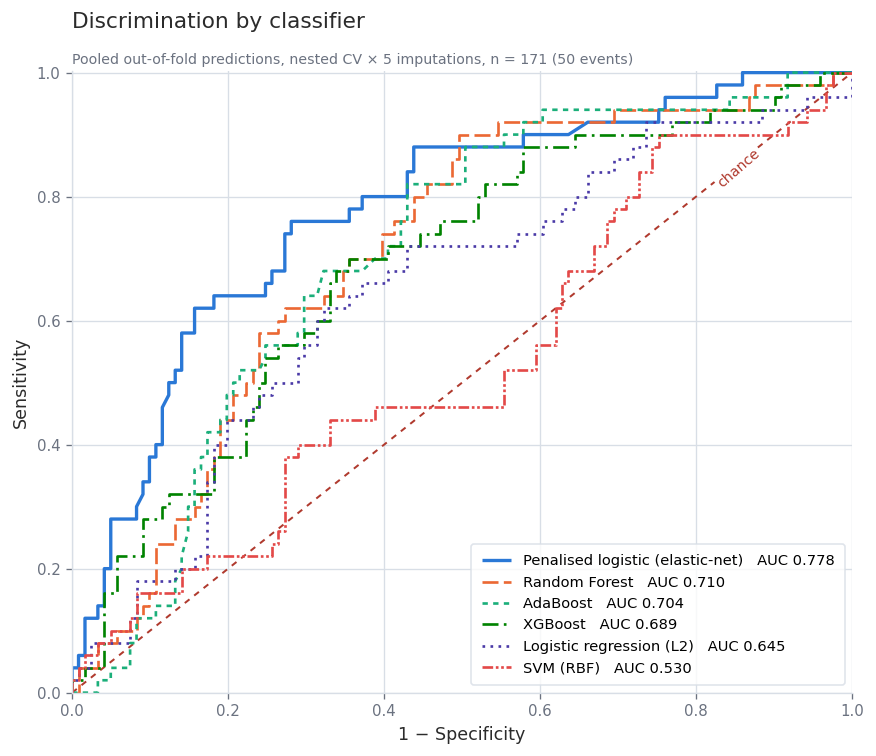

In [19]:
COL  = ["#2a78d6","#eb6834","#1baf7a","#008300","#4a3aa7","#e34948"]
DASH = [(0,()), (0,(6,2)), (0,(2,2)), (0,(6,2,1,2)), (0,(1,2)), (0,(4,1,1,1,1,1))]
INK, MUTED, GRID = "#2B2B2B", "#6B7280", "#D8DEE6"

def _style(ax):
    ax.grid(color=GRID, lw=0.8); ax.set_axisbelow(True)
    for s in ("top","right"): ax.spines[s].set_visible(False)
    for s in ("left","bottom"): ax.spines[s].set_color(GRID)
    ax.tick_params(colors=MUTED, labelsize=9)

order = list(ciB["model"])

fig, ax = plt.subplots(figsize=(7.4, 6.4), dpi=120)
ax.plot([0,1],[0,1], ls=(0,(3,3)), lw=1.2, color="#B03A2E")
ax.text(0.855, 0.815, "chance", fontsize=8.5, color="#B03A2E", rotation=41,
        ha="center", bbox=dict(fc="white", ec="none", pad=1.2))
for k in order:
    fpr, tpr, _ = roc_curve(y, pooled_B[k]); j = order.index(k)
    ax.plot(fpr, tpr, lw=2.0 if j == 0 else 1.6, color=COL[j % 6], ls=DASH[j % 6],
            label=f"{k}   AUC {auc(fpr, tpr):.3f}")
ax.set_xlim(0,1); ax.set_ylim(0,1.002)
ax.set_xlabel("1 − Specificity", fontsize=10.5, color=INK)
ax.set_ylabel("Sensitivity", fontsize=10.5, color=INK)
ax.set_title("Discrimination by classifier", fontsize=13, color=INK, loc="left", pad=26)
ax.text(0, 1.012, f"Pooled out-of-fold predictions, nested CV × {N_IMPUTATIONS} imputations, "
        f"n = {len(y)} ({int(y.sum())} events)", transform=ax.transAxes, fontsize=8.5, color=MUTED)
ax.legend(loc="lower right", fontsize=8.8, frameon=True, edgecolor=GRID, borderpad=0.7)
_style(ax); fig.tight_layout(); savefig(fig, "F10_ROC"); plt.show()

  saved -> figures/F11_PR.png | .pdf


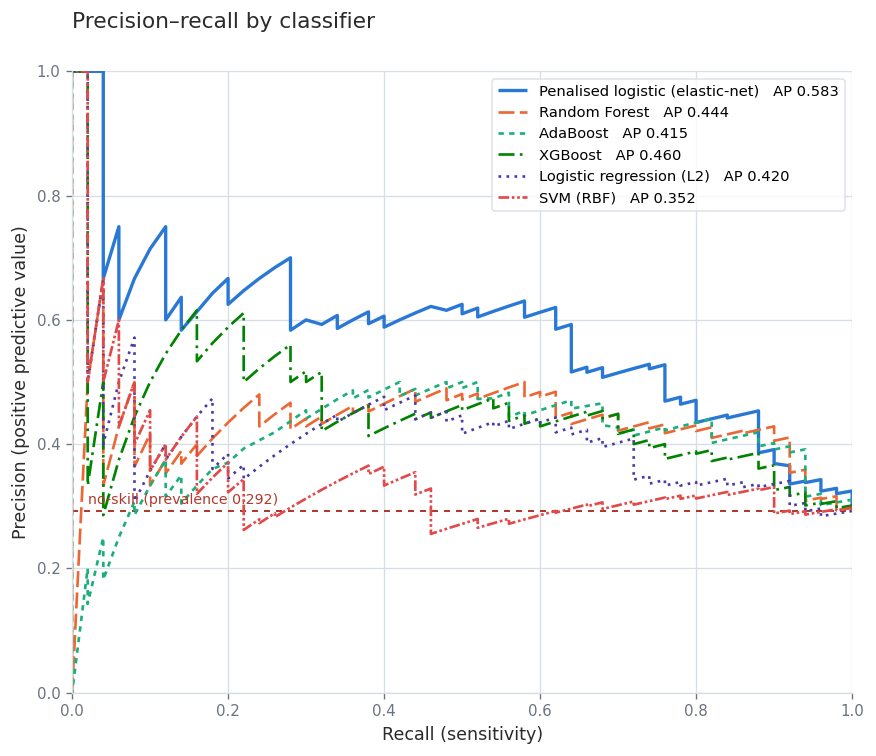

In [20]:
# ---- precision–recall: the more honest view under class imbalance --------------
fig, ax = plt.subplots(figsize=(7.4, 6.4), dpi=120)
prev = float(np.mean(y))
ax.axhline(prev, ls=(0,(3,3)), lw=1.2, color="#B03A2E")
ax.text(0.02, prev+0.012, f"no-skill (prevalence {prev:.3f})", fontsize=8.5, color="#B03A2E")
for k in order:
    pr, rc, _ = precision_recall_curve(y, pooled_B[k]); j = order.index(k)
    ax.plot(rc, pr, lw=2.0 if j == 0 else 1.6, color=COL[j % 6], ls=DASH[j % 6],
            label=f"{k}   AP {average_precision_score(y, pooled_B[k]):.3f}")
ax.set_xlim(0,1); ax.set_ylim(0,1)
ax.set_xlabel("Recall (sensitivity)", fontsize=10.5, color=INK)
ax.set_ylabel("Precision (positive predictive value)", fontsize=10.5, color=INK)
ax.set_title("Precision–recall by classifier", fontsize=13, color=INK, loc="left", pad=26)
ax.legend(loc="upper right", fontsize=8.8, frameon=True, edgecolor=GRID)
_style(ax); fig.tight_layout(); savefig(fig, "F11_PR"); plt.show()

  saved -> figures/F20_calibration_confusion.png | .pdf


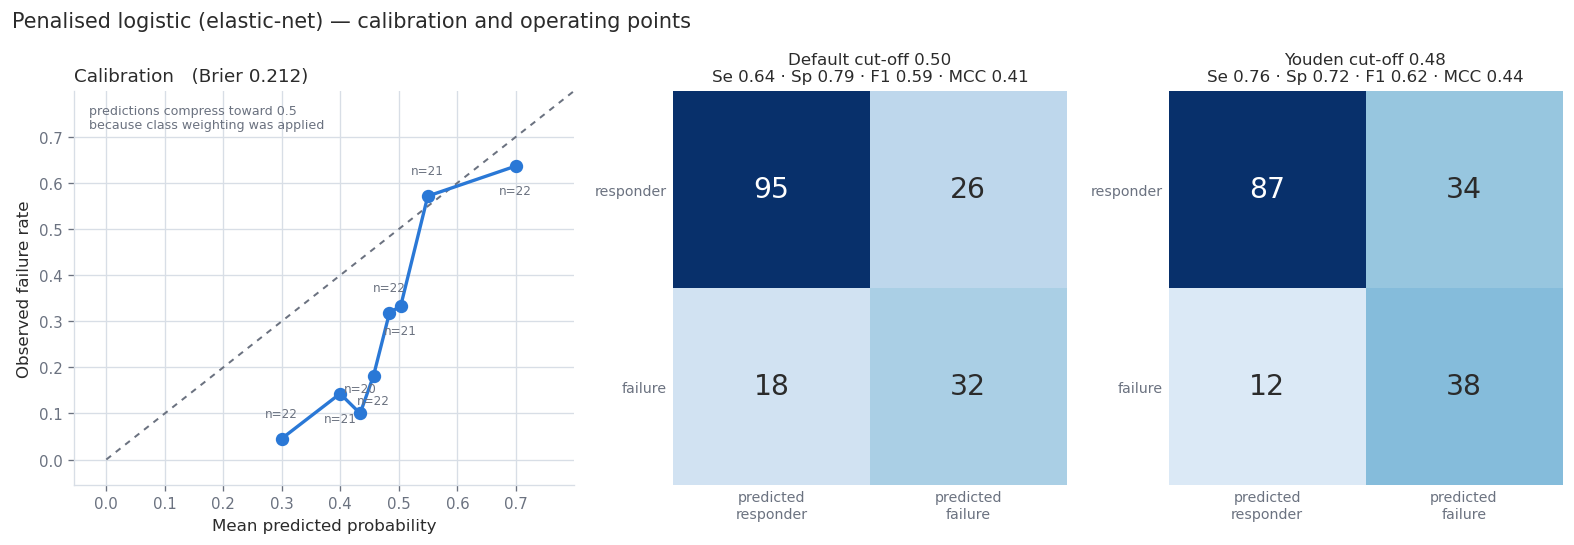

  saved -> tables/T22_operating_points.csv  (2, 13)


,threshold,cut_off,TP,FN,TN,FP,accuracy,f1,mcc,sensitivity,specificity,ppv,npv
0,Default cut-off 0.50,0.5000,32,18,95,26,0.743,0.593,0.408,0.64,0.785,0.552,0.841
1,Youden cut-off 0.48,0.4846,38,12,87,34,0.731,0.623,0.441,0.76,0.719,0.528,0.879


In [21]:
# ---- calibration and operating points of the best classifier -------------------
p_best = pooled_B[BEST]
thr_j  = youden_threshold(y, p_best)

fig, axes = plt.subplots(1, 3, figsize=(13.2, 4.5), dpi=120,
                         gridspec_kw={"width_ratios":[1.25,1,1]})
ax = axes[0]
edges = np.unique(np.quantile(p_best, np.linspace(0,1,9)))
idx = np.clip(np.digitize(p_best, edges[1:-1]), 0, len(edges)-2)
xs, ys, ns = [], [], []
for b in range(len(edges)-1):
    s = idx == b
    if s.sum() >= 3:
        xs.append(p_best[s].mean()); ys.append(y[s].mean()); ns.append(int(s.sum()))
ax.plot([0,1],[0,1], ls=(0,(3,3)), color=MUTED, lw=1.2)
ax.plot(xs, ys, "o-", lw=2, ms=7, color=COL[0])
for i,(a,b,nn) in enumerate(zip(xs,ys,ns)):
    ax.annotate(f"n={nn}", (a,b), textcoords="offset points",
                xytext=(0, 13 if i%2==0 else -17), fontsize=7.2, color=MUTED, ha="center")
lo_x = min(min(xs),min(ys))-0.10; hi_x = max(max(xs),max(ys))+0.10
ax.set_xlim(lo_x,hi_x); ax.set_ylim(lo_x,hi_x)
ax.set_xlabel("Mean predicted probability", fontsize=10, color=INK)
ax.set_ylabel("Observed failure rate", fontsize=10, color=INK)
ax.set_title(f"Calibration   (Brier {brier_score_loss(y,p_best):.3f})",
             fontsize=11, color=INK, loc="left")
ax.text(0.03, 0.965, "predictions compress toward 0.5\nbecause class weighting was applied",
        transform=ax.transAxes, fontsize=7.6, color=MUTED, va="top")
_style(ax)

op_rows = []
for ax, (t, lab) in zip(axes[1:], [(0.5,"Default cut-off 0.50"), (thr_j,f"Youden cut-off {thr_j:.2f}")]):
    cm = confusion_matrix(y, (p_best>=t).astype(int), labels=[0,1])
    ax.imshow(cm, cmap="Blues", vmin=0, vmax=cm.max())
    for i in range(2):
        for jj in range(2):
            ax.text(jj, i, str(cm[i,jj]), ha="center", va="center", fontsize=17,
                    color="white" if cm[i,jj] > cm.max()*0.55 else INK)
    mt = binary_metrics(y, p_best, threshold=t)
    op_rows.append({"threshold": lab, "cut_off": round(t,4),
                    "TP":cm[1,1], "FN":cm[1,0], "TN":cm[0,0], "FP":cm[0,1],
                    **{k: round(v,3) for k,v in mt.items()
                       if k in ("sensitivity","specificity","ppv","npv","f1","mcc","accuracy")}})
    ax.set_xticks([0,1]); ax.set_xticklabels(["predicted\nresponder","predicted\nfailure"], fontsize=8.5)
    ax.set_yticks([0,1]); ax.set_yticklabels(["responder","failure"], fontsize=8.5)
    ax.set_title(f"{lab}\nSe {mt['sensitivity']:.2f} · Sp {mt['specificity']:.2f} · "
                 f"F1 {mt['f1']:.2f} · MCC {mt['mcc']:.2f}", fontsize=10, color=INK)
    for s in ax.spines.values(): s.set_visible(False)
    ax.tick_params(length=0, colors=MUTED)
fig.suptitle(f"{BEST} — calibration and operating points", fontsize=12.5,
             color=INK, x=0.008, ha="left", y=1.0)
fig.tight_layout(); savefig(fig, "F20_calibration_confusion"); plt.show()

op = pd.DataFrame(op_rows); save_table(op, "T22_operating_points"); display(op)

## 7. Where does the predictive signal come from?

The decisive analysis. Satisfaction at month 6 defines the outcome, while satisfaction
at earlier visits is a predictor — so the reported performance could be model skill, or
it could be nothing more than the persistence of satisfaction over time.

A ladder of nested models separates the two. All rows use the identical protocol, so
the paired bootstrap comparison is valid.

In [22]:
SAT = [c for c in ["satisfactionV2","satisfactionV3"] if c in X_full.columns]
simple_spec = SPECS.get("Logistic regression (L2)") or list(SPECS.values())[0]
full_spec   = SPECS[BEST]

LADDER = {
 "Satisfaction at month 3 alone":              (["satisfactionV3"], simple_spec, False),
 "Satisfaction trajectory (week 2 + month 3)": (SAT,                simple_spec, True),
 "Small clinical model (5 variables)":         ([c for c in ["satisfactionV3","allerganV3",
                                                  "pain","age","group"] if c in X_full.columns],
                                                simple_spec, False),
 "Full predictor set, satisfaction removed":   ([c for c in X_full.columns if c not in SAT],
                                                full_spec, True),
 f"Full model ({BEST})":                       (list(X_full.columns), full_spec, True),
}

def oof_for(cols, spec, deltas):
    outer = StratifiedKFold(OUTER_SPLITS, shuffle=True, random_state=SEED)
    inner = StratifiedKFold(INNER_SPLITS, shuffle=True, random_state=SEED)
    Xi, acc = X_full[cols], []
    for m in range(N_IMPUTATIONS):
        p = np.full(len(y), np.nan)
        for tr, te in outer.split(Xi, y):
            feat = make_feature_pipeline(SEED + 1000*m, spec.needs_scaling, deltas)
            s = make_search(spec, feat, inner); s.fit(Xi.iloc[tr], y[tr])
            p[te] = s.predict_proba(Xi.iloc[te])[:, 1]
        acc.append(p)
    return np.mean(np.vstack(acc), axis=0)

t0 = time.time(); ladder_p = {}
for name, (cols, spec, dl) in LADDER.items():
    print(f"  fitting: {name}  ({len(cols)} variables)", flush=True)
    ladder_p[name] = oof_for(cols, spec, dl)
print(f"ladder finished in {time.time()-t0:.0f}s")

rows = []
for name, p in ladder_p.items():
    pt, lo, hi = bootstrap_auc_ci(y, p)
    rows.append({"model":name, "n_variables":len(LADDER[name][0]),
                 "AUC":round(pt,3), "CI95_low":round(lo,3), "CI95_high":round(hi,3)})
ladder = pd.DataFrame(rows); save_table(ladder, "T30_model_ladder"); display(ladder)

FULL_KEY = f"Full model ({BEST})"
cmp_rows = []
for name, p in ladder_p.items():
    if name == FULL_KEY: continue
    r = paired_auc_test(y, ladder_p[FULL_KEY], p)
    cmp_rows.append({"comparison": f"full model vs {name}", "delta_AUC": round(r["auc_diff"],3),
                     "CI95_low": round(r["ci_low"],3), "CI95_high": round(r["ci_high"],3),
                     "p_value": round(r["p_value"],4)})
ladder_tests = pd.DataFrame(cmp_rows)
save_table(ladder_tests, "T31_model_ladder_tests"); display(ladder_tests)

  fitting: Satisfaction at month 3 alone  (1 variables)
  fitting: Satisfaction trajectory (week 2 + month 3)  (2 variables)
  fitting: Small clinical model (5 variables)  (5 variables)
  fitting: Full predictor set, satisfaction removed  (35 variables)
  fitting: Full model (Penalised logistic (elastic-net))  (37 variables)
ladder finished in 809s
  saved -> tables/T30_model_ladder.csv  (5, 5)


,model,n_variables,AUC,CI95_low,CI95_high
0,Satisfaction at month 3 alone,1,0.792,0.714,0.866
1,Satisfaction trajectory (week 2 + month 3),2,0.766,0.685,0.843
2,Small clinical model (5 variables),5,0.793,0.716,0.869
3,"Full predictor set, satisfaction removed",35,0.485,0.394,0.584
4,Full model (Penalised logistic (elastic-net)),37,0.778,0.701,0.850


  saved -> tables/T31_model_ladder_tests.csv  (4, 5)


,comparison,delta_AUC,CI95_low,CI95_high,p_value
0,full model vs Satisfaction at month 3 alone,-0.015,-0.046,0.019,0.391
1,full model vs Satisfaction trajectory (week 2 ...,0.011,-0.017,0.042,0.424
2,full model vs Small clinical model (5 variables),-0.016,-0.068,0.033,0.549
3,"full model vs Full predictor set, satisfaction...",0.293,0.181,0.402,0.000


  saved -> figures/F30_model_ladder.png | .pdf


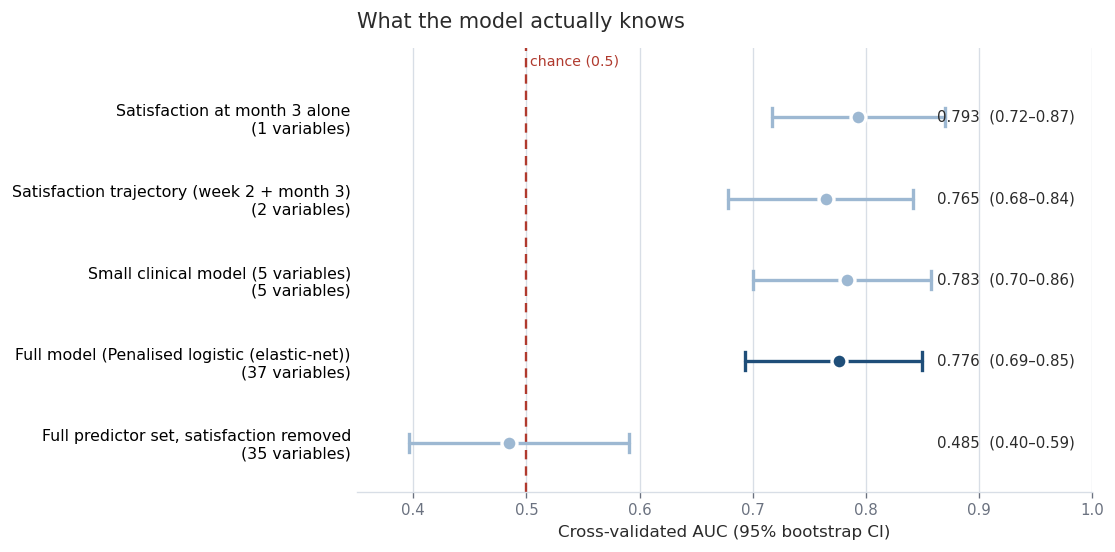

In [24]:
# ---- the figure that answers the question --------------------------------------
ACCENT, MUTED2 = "#1F4E79", "#9DB8D2"
t = ladder.set_index("model").loc[[k for k in LADDER if k != "Full predictor set, satisfaction removed"]
                                  + ["Full predictor set, satisfaction removed"]].reset_index()
cols_ = [ACCENT if m == FULL_KEY else MUTED2 for m in t["model"]]
ypos = np.arange(len(t))[::-1]

fig, ax = plt.subplots(figsize=(9.4, 4.7), dpi=120)
ax.axvline(0.5, color="#B03A2E", lw=1.4, ls=(0,(4,3)))
ax.text(0.503, len(t)-0.32, "chance (0.5)", color="#B03A2E", fontsize=8.5, va="center")
for i, r in t.iterrows():
    ax.plot([r.CI95_low, r.CI95_high], [ypos[i]]*2, color=cols_[i], lw=2.0, solid_capstyle="round")
    for x in (r.CI95_low, r.CI95_high):
        ax.plot([x,x], [ypos[i]-.11, ypos[i]+.11], color=cols_[i], lw=2.0)
    ax.plot(r.AUC, ypos[i], "o", ms=9, color=cols_[i], markeredgecolor="white", markeredgewidth=2)
    ax.text(0.985, ypos[i], f"{r.AUC:.3f}  ({r.CI95_low:.2f}–{r.CI95_high:.2f})",
            va="center", ha="right", fontsize=9, color=INK)
ax.set_yticks(ypos)
ax.set_yticklabels([f"{m}\n({n} variables)" for m, n in zip(t["model"], t["n_variables"])], fontsize=9.5)
ax.set_xlim(0.35, 1.0); ax.set_ylim(-0.6, len(t)-0.15)
ax.set_xlabel("Cross-validated AUC (95% bootstrap CI)", fontsize=10, color=INK)
ax.set_title("What the model actually knows", fontsize=12.5, color=INK, loc="left", pad=12)
ax.xaxis.grid(True, color=GRID, lw=0.8); ax.set_axisbelow(True)
for s in ("top","right","left"): ax.spines[s].set_visible(False)
ax.spines["bottom"].set_color(GRID); ax.tick_params(axis="y", length=0)
ax.tick_params(axis="x", colors=MUTED, labelsize=9)
fig.tight_layout(); savefig(fig, "F30_model_ladder"); plt.show()

## 8. Explainability

In [23]:
# refit the best model on the whole sample — for explanation only, never for reporting
inner = StratifiedKFold(INNER_SPLITS, shuffle=True, random_state=SEED)
feat  = make_feature_pipeline(SEED, full_spec.needs_scaling, True)
gs    = make_search(full_spec, feat, inner); gs.fit(X_full, y)
final_model = gs.best_estimator_
print(f"inner-CV AUC : {gs.best_score_:.3f}")
print(f"best params  : {gs.best_params_}")

clf = final_model.named_steps["model"]
if hasattr(clf, "coef_"):
    names = list(final_model.named_steps["features"].named_steps["encode"].get_feature_names_out())
    coef  = np.asarray(clf.coef_).ravel()
    coefs = (pd.DataFrame({"feature":names, "coefficient":coef, "odds_ratio":np.exp(coef)})
             .assign(abs_coef=lambda d: d.coefficient.abs())
             .sort_values("abs_coef", ascending=False).drop(columns="abs_coef")
             .reset_index(drop=True))
    nz = coefs[coefs.coefficient.abs() > 1e-10]
    print(f"\npredictors entering the model: {len(nz)} of {len(coefs)}")
    save_table(coefs, "T32_coefficients"); display(nz.round(4))
else:
    print("\nfinal model is not linear — see permutation importance below")

inner-CV AUC : 0.811
best params  : {'model__C': 0.1, 'model__l1_ratio': 0.85}

predictors entering the model: 7 of 79
  saved -> tables/T32_coefficients.csv  (79, 3)


,feature,coefficient,odds_ratio
0,satisfactionV3,-0.8983,0.4073
1,depthL__dV2_V0,-0.0655,0.9366
2,depthL__rV3_V0,-0.0488,0.9523
3,allergan2V2,0.0307,1.0312
4,allerganV3,0.0256,1.0259
5,allerganV2,0.0210,1.0212
6,allerganV0,0.0047,1.0047


  saved -> tables/T33_permutation_importance.csv  (37, 3)


,feature,importance_mean,importance_sd
0,satisfactionV3,0.300997,0.046035
1,depthLV0,0.010829,0.006931
2,depthLV2,0.008157,0.005127
3,depthLV3,0.006915,0.003892
4,satisfactionV2,0.003306,0.006279
5,allergan2V2,0.002992,0.001721
6,allerganV3,0.002490,0.001388
7,allerganV2,0.002099,0.001417
8,allerganV0,0.000364,0.000382
9,areaRV0,0.000000,0.000000


  saved -> figures/F40_permutation_importance.png | .pdf


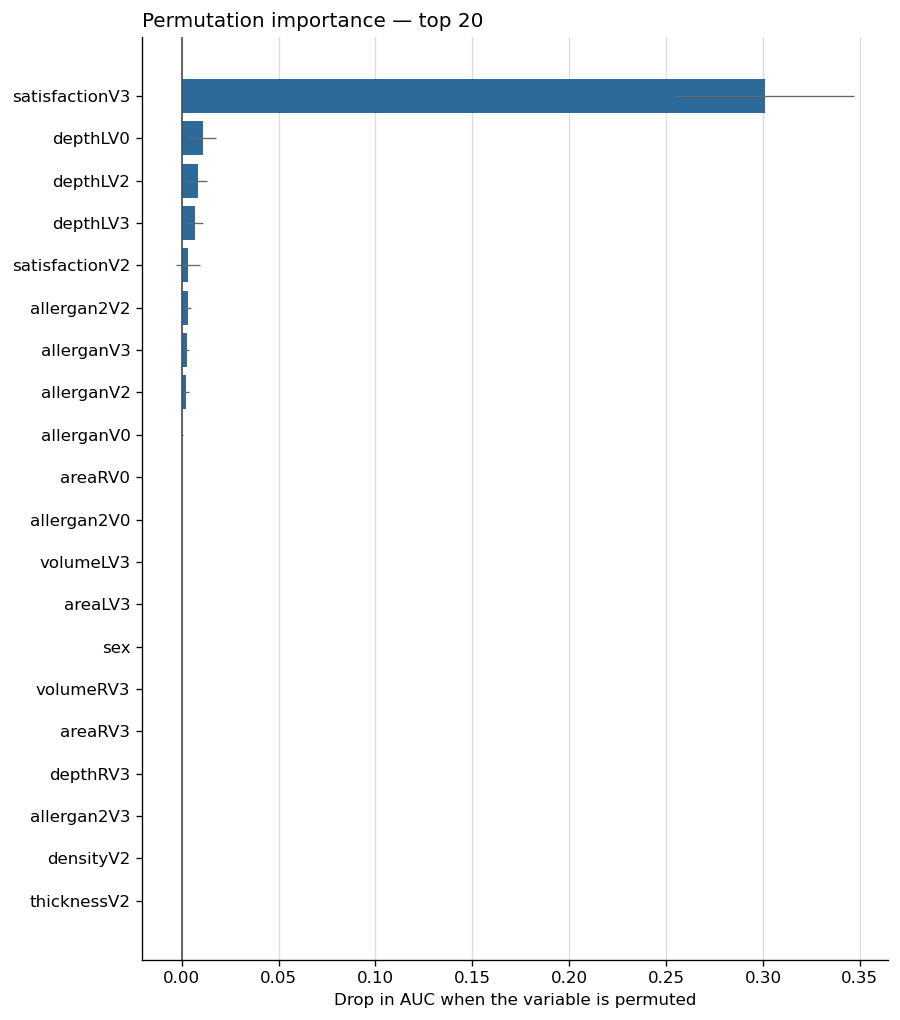

In [24]:
# ---- permutation importance: the unbiased alternative to impurity importance ----
r = permutation_importance(final_model, X_full, y, scoring="roc_auc",
                           n_repeats=10 if FAST_MODE else 30, random_state=SEED, n_jobs=1)
imp = (pd.DataFrame({"feature":X_full.columns, "importance_mean":r.importances_mean,
                     "importance_sd":r.importances_std})
       .sort_values("importance_mean", ascending=False).reset_index(drop=True))
save_table(imp, "T33_permutation_importance"); display(imp.head(15))

top = imp.head(20).iloc[::-1]
fig, ax = plt.subplots(figsize=(7.6, 0.34*len(top)+1.8), dpi=120)
ax.barh(top.feature, top.importance_mean, xerr=top.importance_sd,
        color="#2b6a9b", error_kw={"lw":0.8, "ecolor":"0.4"})
ax.axvline(0, color="0.3", lw=1)
ax.set_xlabel("Drop in AUC when the variable is permuted", fontsize=10)
ax.set_title("Permutation importance — top 20", fontsize=12, loc="left")
ax.grid(axis="x", color=GRID, lw=0.8); ax.set_axisbelow(True)
for s in ("top","right"): ax.spines[s].set_visible(False)
fig.tight_layout(); savefig(fig, "F40_permutation_importance"); plt.show()

PermutationExplainer explainer: 151it [00:31,  4.01it/s]                                                               

explainer: PermutationExplainer
  saved -> tables/T34_shap_importance.csv  (79, 2)


,feature,mean_abs_shap
0,satisfactionV3,0.153736
1,depthL__dV2_V0,0.010257
2,depthL__rV3_V0,0.007966
3,allergan2V2,0.005335
4,allerganV3,0.004804
5,allerganV2,0.003243
6,allerganV0,0.000820
7,volumeR__dV3_V2,0.000000
8,depthL__dV3_V0,0.000000
9,depthL__dV3_V2,0.000000


  saved -> figures/F41_shap_beeswarm.png | .pdf


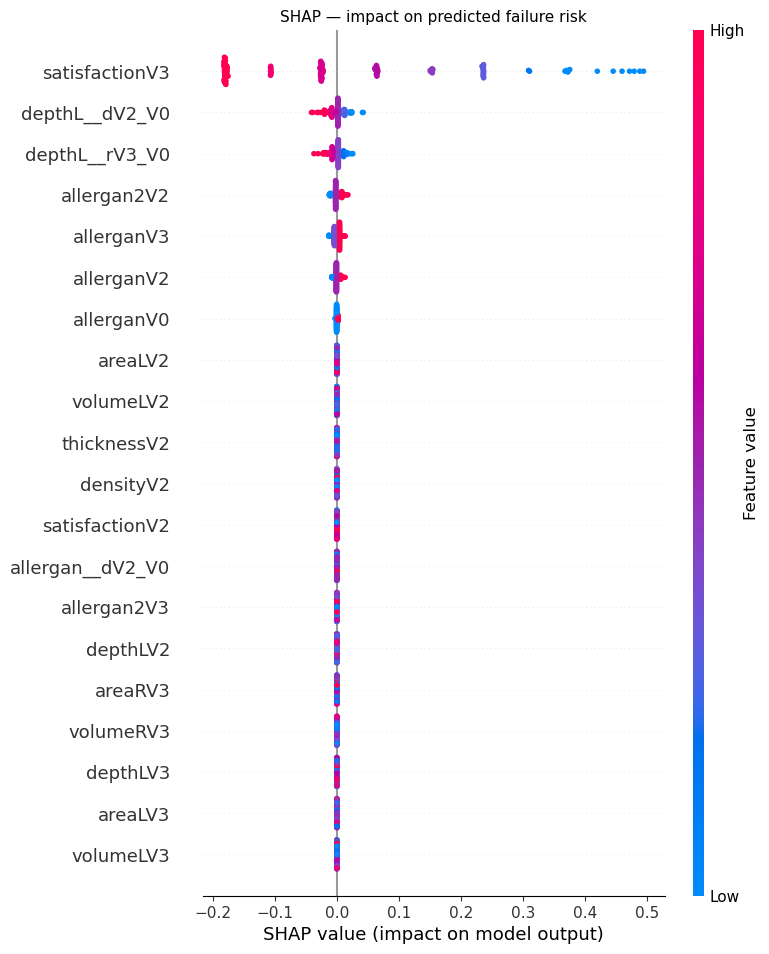

In [25]:
# ---- SHAP ----------------------------------------------------------------------
try:
    import shap
    feats_ = final_model.named_steps["features"]
    Xt = pd.DataFrame(np.asarray(feats_.transform(X_full)),
                      columns=list(feats_.named_steps["encode"].get_feature_names_out()))
    assert not Xt.isna().any().any(), "NaNs survived preprocessing"
    idx = np.random.RandomState(SEED).choice(len(Xt), min(150 if not FAST_MODE else 40, len(Xt)),
                                             replace=False)
    X_exp = Xt.iloc[idx]

    sv2d = None
    try:
        raw = shap.TreeExplainer(clf).shap_values(X_exp, check_additivity=False)
        raw = np.asarray(raw[1] if isinstance(raw, list) and len(raw) > 1 else raw)
        sv2d = raw[:, :, 1] if raw.ndim == 3 else raw
        print("explainer: TreeExplainer")
    except Exception:
        bg = shap.sample(Xt, min(50, len(Xt)), random_state=SEED)
        ex = shap.Explainer(clf.predict_proba, bg)(X_exp, max_evals=800 if FAST_MODE else 2000)
        vals = np.asarray(ex.values)
        sv2d = vals[:, :, 1] if vals.ndim == 3 else vals
        print("explainer: PermutationExplainer")

    tab = (pd.DataFrame({"feature": Xt.columns, "mean_abs_shap": np.abs(sv2d).mean(axis=0)})
           .sort_values("mean_abs_shap", ascending=False).reset_index(drop=True))
    save_table(tab, "T34_shap_importance"); display(tab.head(15))

    shap.summary_plot(sv2d, X_exp, max_display=20, show=False)
    plt.title("SHAP — impact on predicted failure risk", fontsize=11)
    savefig(plt.gcf(), "F41_shap_beeswarm"); plt.show()
except ImportError:
    print("shap not installed — skipping (pip install shap)")
except Exception as exc:
    print(f"SHAP failed: {type(exc).__name__}: {exc}")

## 9. Sensitivity analysis — does the conclusion depend on the cut-off?

The 7/10 threshold is a convention, not a measurement. If discrimination collapses at 6
or 8, the model is tracking one arbitrary bin boundary rather than dissatisfaction.

  threshold<6  A_baseline   Penalised logistic (elastic-net)   AUC=0.545
  threshold<6  A_baseline   Logistic regression (L2)           AUC=0.560
  threshold<6  B_full       Penalised logistic (elastic-net)   AUC=0.724
  threshold<6  B_full       Logistic regression (L2)           AUC=0.668
  threshold<7  A_baseline   Penalised logistic (elastic-net)   AUC=0.497
  threshold<7  A_baseline   Logistic regression (L2)           AUC=0.486
  threshold<7  B_full       Penalised logistic (elastic-net)   AUC=0.781
  threshold<7  B_full       Logistic regression (L2)           AUC=0.616
  threshold<8  A_baseline   Penalised logistic (elastic-net)   AUC=0.627
  threshold<8  A_baseline   Logistic regression (L2)           AUC=0.631
  threshold<8  B_full       Penalised logistic (elastic-net)   AUC=0.808
  threshold<8  B_full       Logistic regression (L2)           AUC=0.700
  saved -> tables/T40_threshold_sensitivity.csv  (12, 5)


threshold                                      6.0    7.0    8.0
scenario   model                                                
A_baseline Logistic regression (L2)          0.560  0.486  0.631
           Penalised logistic (elastic-net)  0.545  0.497  0.627
B_full     Logistic regression (L2)          0.668  0.616  0.700
           Penalised logistic (elastic-net)  0.724  0.781  0.808

  saved -> figures/F50_threshold_sensitivity.png | .pdf


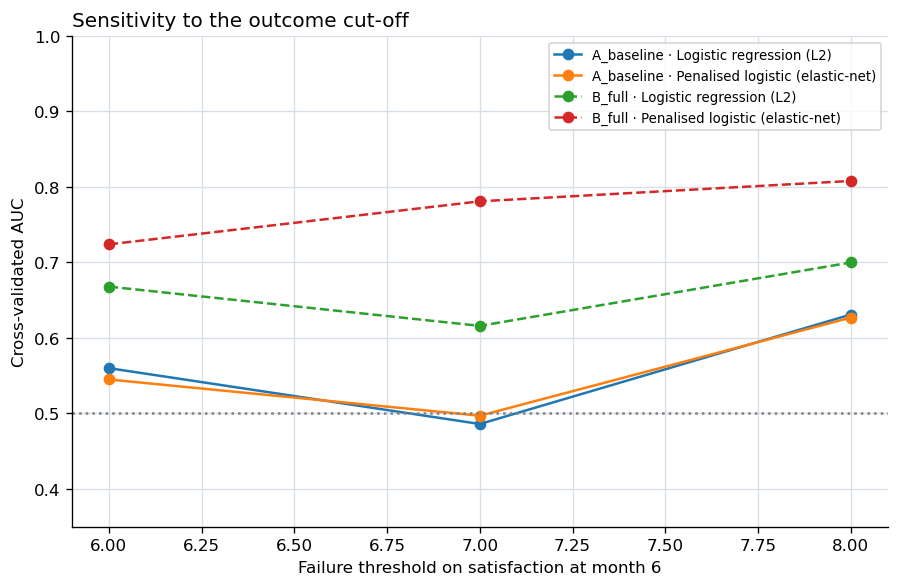

In [26]:
rows, outer = [], StratifiedKFold(OUTER_SPLITS, shuffle=True, random_state=SEED)
inner = StratifiedKFold(INNER_SPLITS, shuffle=True, random_state=SEED)
probe = [full_spec] + ([simple_spec] if simple_spec.name != full_spec.name else [])

for thr in SENSITIVITY_THRESHOLDS:
    y_thr = (df[TARGET_CONT].astype(float) < thr).astype(int).values
    for scen, Xs in SCENARIOS.items():
        for spec in probe:
            feat = make_feature_pipeline(SEED, spec.needs_scaling, scen.startswith("B"))
            try:
                p = cross_val_predict(make_search(spec, feat, inner), Xs, y_thr,
                                      cv=outer, method="predict_proba", n_jobs=1)[:, 1]
                a = roc_auc_score(y_thr, p)
            except Exception as exc:
                print(f"  [skip] {thr} {scen} {spec.name}: {exc}"); continue
            rows.append({"threshold":thr, "n_failures":int(y_thr.sum()), "scenario":scen,
                         "model":spec.name, "AUC":round(float(a),3)})
            print(f"  threshold<{thr:g}  {scen:<12} {spec.name:<34} AUC={a:.3f}", flush=True)

sens = pd.DataFrame(rows); save_table(sens, "T40_threshold_sensitivity")
display(sens.pivot_table(index=["scenario","model"], columns="threshold", values="AUC"))

if len(sens):
    fig, ax = plt.subplots(figsize=(7.6, 5.0), dpi=120)
    for (scen, nm), gsub in sens.groupby(["scenario","model"]):
        ax.plot(gsub.threshold, gsub.AUC, marker="o",
                ls="-" if scen.startswith("A") else "--", label=f"{scen} · {nm}")
    ax.axhline(0.5, ls=":", color="0.5")
    ax.set_xlabel("Failure threshold on satisfaction at month 6")
    ax.set_ylabel("Cross-validated AUC"); ax.set_ylim(0.35, 1.0)
    ax.set_title("Sensitivity to the outcome cut-off", fontsize=12, loc="left")
    ax.legend(fontsize=8); ax.grid(color=GRID, lw=0.8); ax.set_axisbelow(True)
    for s in ("top","right"): ax.spines[s].set_visible(False)
    fig.tight_layout(); savefig(fig, "F50_threshold_sensitivity"); plt.show()

## 10. Export everything

In [27]:
csvs = sorted((OUTDIR/"tables").glob("*.csv"))
xlsx = OUTDIR/"HA_filler_all_results.xlsx"
with pd.ExcelWriter(xlsx, engine="openpyxl") as xw:
    for f in csvs:
        try:
            pd.read_csv(f).to_excel(xw, sheet_name=f.stem[:31], index=False)
        except Exception as exc:
            print(f"  [skip] {f.name}: {exc}")

meta = {"mode": "FAST" if FAST_MODE else "FULL", "seed": SEED,
        "n_imputations": N_IMPUTATIONS, "outer_splits": OUTER_SPLITS,
        "inner_splits": INNER_SPLITS, "n_analysed": int(len(df)),
        "n_failures": int(y.sum()), "failure_rate": round(float(y.mean()), 4),
        "no_information_rate": round(NO_INFO_RATE, 4), "best_classifier": BEST}
(OUTDIR/"run_metadata.json").write_text(json.dumps(meta, indent=2))

print(f"workbook : {xlsx}  ({len(csvs)} sheets)")
print(f"figures  : {len(list((OUTDIR/'figures').glob('*.png')))} PNG + PDF")
print(f"metadata : {OUTDIR/'run_metadata.json'}")
print("\n" + "="*70)
print("DONE" + ("  —  this was the FAST pass; set FAST_MODE = False and re-run"
                if FAST_MODE else ""))
print("="*70)

workbook : results\HA_filler_all_results.xlsx  (17 sheets)
figures  : 7 PNG + PDF
metadata : results\run_metadata.json

DONE
